# Time Series Analysis: Ukraine Air Raid Alerts (2022-2026)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data using the exact filename from your folder
df_raw = pd.read_csv('clean_air_raid_data.csv') 

# 2. Convert times to datetime objects so Python can read them (handles UTC)
df_raw['started_at'] = pd.to_datetime(df_raw['started_at'])
df_raw['finished_at'] = pd.to_datetime(df_raw['finished_at'])

# 3. Create the duration column
df_raw['duration_minutes'] = (df_raw['finished_at'] - df_raw['started_at']).dt.total_seconds() / 60

# 4. Create the cleaned dataset variable that all our other charts rely on
df_clean = df_raw.copy()

print("Data successfully loaded from clean_air_raid_data.csv and ready for analysis!")

Data successfully loaded from clean_air_raid_data.csv and ready for analysis!


## Part 1: The True Timeline

Filtering outliers and running Time-Union Algorithm... Please wait.
Algorithm complete! Drawing the true timeline...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_63309/2790930446.py:28: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)


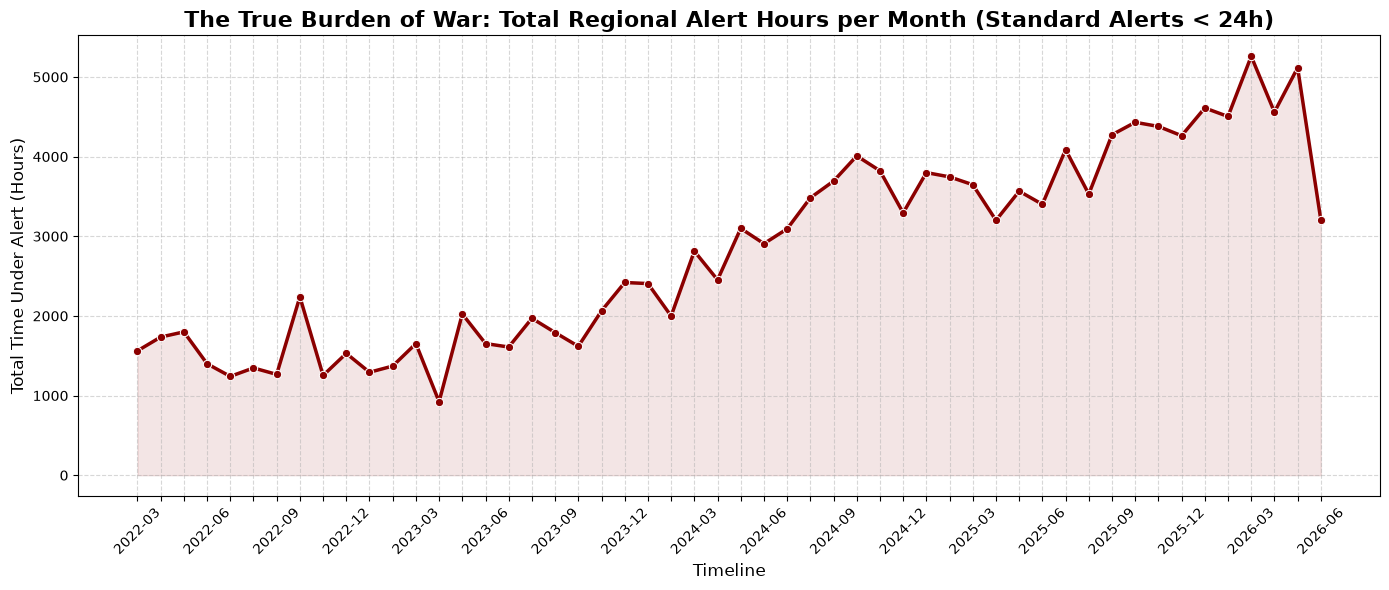

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Filtering outliers and running Time-Union Algorithm... Please wait.")

# --- THE FIX: REMOVE OUTLIERS ---
# Only keep alerts that lasted less than 24 hours (1440 minutes)
# We use duration_minutes because we know it already exists in df_clean!
df_standard = df_clean[df_clean['duration_minutes'] < 1440].copy()

# --- THE DATA ENGINEERING (Collapsing Overlaps) ---
temp_df = df_standard.sort_values(['oblast', 'started_at']).copy()

temp_df['max_end_so_far'] = temp_df.groupby('oblast')['finished_at'].cummax().shift()
temp_df['max_end_so_far'] = temp_df['max_end_so_far'].fillna(temp_df['started_at'])
temp_df['is_new_alert'] = temp_df['started_at'] > temp_df['max_end_so_far']
temp_df['alert_id'] = temp_df.groupby('oblast')['is_new_alert'].cumsum()

true_alerts = temp_df.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

true_alerts['true_duration_hours'] = (true_alerts['true_end'] - true_alerts['true_start']).dt.total_seconds() / 3600

# Group by Month to get the final national timeline
true_alerts['year_month'] = true_alerts['true_start'].dt.to_period('M').astype(str)
final_timeline = true_alerts.groupby('year_month')['true_duration_hours'].sum().reset_index()

print("Algorithm complete! Drawing the true timeline...")

# --- THE VISUALIZATION ---
plt.figure(figsize=(14, 6))

sns.lineplot(data=final_timeline, x='year_month', y='true_duration_hours', marker="o", color="darkred", linewidth=2.5)

plt.title("The True Burden of War: Total Regional Alert Hours per Month (Standard Alerts < 24h)", fontsize=16, fontweight="bold")
plt.xlabel("Timeline", fontsize=12)
plt.ylabel("Total Time Under Alert (Hours)", fontsize=12)

ax = plt.gca()
for index, label in enumerate(ax.xaxis.get_ticklabels()):
    if index % 3 != 0: 
        label.set_visible(False)

plt.xticks(rotation=45)
plt.grid(True, linestyle="--", alpha=0.5)
plt.fill_between(final_timeline['year_month'], final_timeline['true_duration_hours'], color="darkred", alpha=0.1)
plt.tight_layout()

plt.show()

## Part 2: Tactical Pattern (Hour of Day)

Converting to local time and analyzing tactical patterns...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_63309/655384637.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=hourly_pattern, x='hour_of_day', y='attack_count', palette=colors)


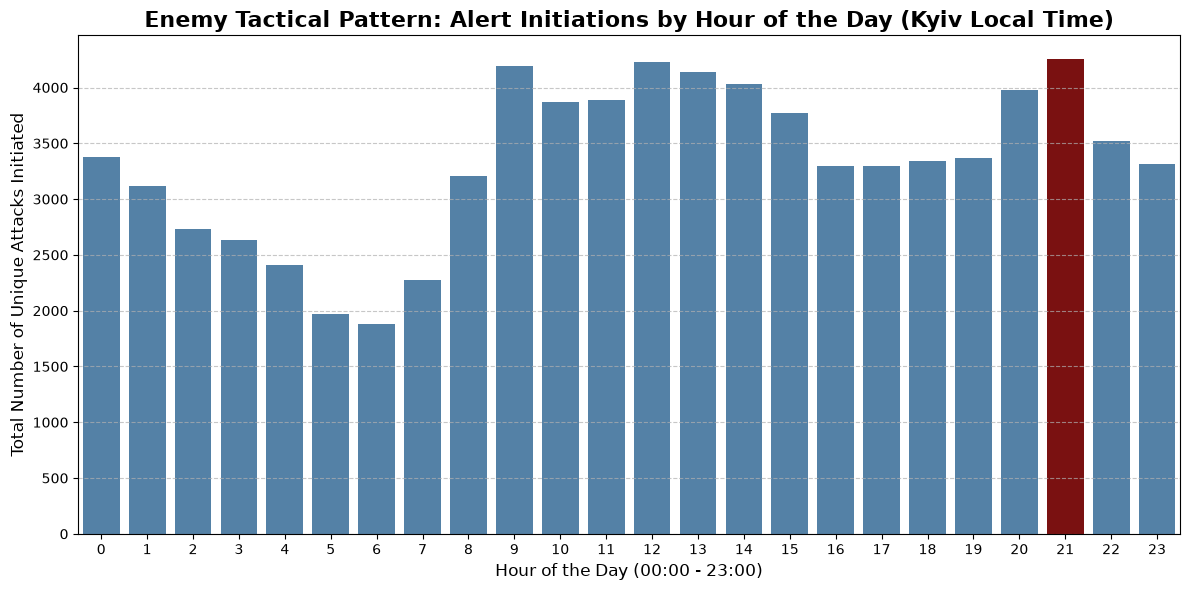

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Converting to local time and analyzing tactical patterns...")

# --- THE DATA ENGINEERING ---

# 1. Convert the UTC computer time to actual Ukrainian local time
true_alerts['kyiv_time'] = true_alerts['true_start'].dt.tz_convert('Europe/Kyiv')

# 2. Extract strictly the hour of the day the attack was INITIATED (0 to 23)
true_alerts['hour_of_day'] = true_alerts['kyiv_time'].dt.hour

# 3. Count how many unique attacks were launched during each hour over the whole war
hourly_pattern = true_alerts.groupby('hour_of_day').size().reset_index(name='attack_count')

# --- THE VISUALIZATION ---

plt.figure(figsize=(12, 6))

# 4. Find the absolute peak hour so we can highlight it visually
peak_hour = hourly_pattern['attack_count'].max()
colors = ['darkred' if count == peak_hour else 'steelblue' for count in hourly_pattern['attack_count']]

# Draw the bar chart
sns.barplot(data=hourly_pattern, x='hour_of_day', y='attack_count', palette=colors)

# Professional Formatting
plt.title("Enemy Tactical Pattern: Alert Initiations by Hour of the Day (Kyiv Local Time)", fontsize=16, fontweight="bold")
plt.xlabel("Hour of the Day (00:00 - 23:00)", fontsize=12)
plt.ylabel("Total Number of Unique Attacks Initiated", fontsize=12)

# Add gridlines to make it easy to read across
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=0)
plt.tight_layout()

# Display the chart
plt.show()

## Part 3: The Geographic Burden

Processing geographic data and building split-pane dashboard...
Dashboard rendering...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_63309/29360591.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=geo_ranking.head(15), x='true_hours', y='oblast', palette="Reds_r", ax=ax_main)


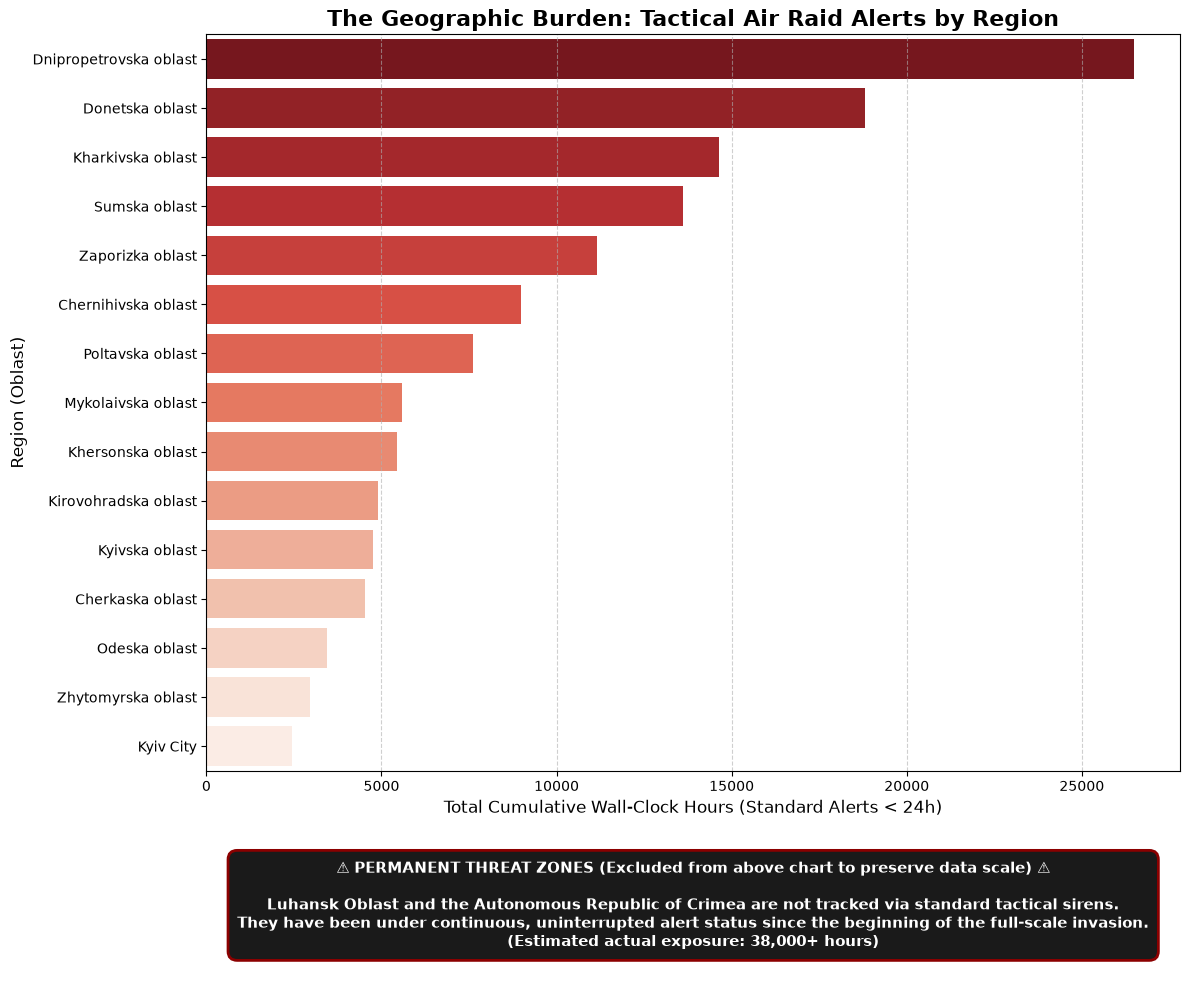

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Processing geographic data and building split-pane dashboard...")

# --- THE DATA ENGINEERING ---

# 1. Isolate standard tactical alerts (under 24 hours)
df_geo_clean = df_clean[df_clean['duration_minutes'] < 1440].copy()

# 2. Sort and prepare for interval union
temp_geo = df_geo_clean.sort_values(['oblast', 'started_at']).copy()

# 3. Collapse overlaps into a single regional clock
temp_geo['max_end_so_far'] = temp_geo.groupby('oblast')['finished_at'].cummax().shift()
temp_geo['max_end_so_far'] = temp_geo['max_end_so_far'].fillna(temp_geo['started_at'])
temp_geo['is_new_alert'] = temp_geo['started_at'] > temp_geo['max_end_so_far']
temp_geo['alert_id'] = temp_geo.groupby('oblast')['is_new_alert'].cumsum()

collapsed_geo = temp_geo.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

# 4. Calculate total hours and rank regions
collapsed_geo['true_hours'] = (collapsed_geo['true_end'] - collapsed_geo['true_start']).dt.total_seconds() / 3600
geo_ranking = collapsed_geo.groupby('oblast')['true_hours'].sum().reset_index()
geo_ranking = geo_ranking.sort_values(by='true_hours', ascending=False)

print("Dashboard rendering...")

# --- THE VISUALIZATION (Split-Pane Layout) ---

# Create a figure with 2 sections. 
# 'height_ratios: [5, 1]' means the top chart gets 5x more space than the bottom banner.
fig, (ax_main, ax_perm) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [5, 1]})

# --- PANE 1: The Standard Leaderboard ---
sns.barplot(data=geo_ranking.head(15), x='true_hours', y='oblast', palette="Reds_r", ax=ax_main)
ax_main.set_title("The Geographic Burden: Tactical Air Raid Alerts by Region", fontsize=16, fontweight="bold")
ax_main.set_xlabel("Total Cumulative Wall-Clock Hours (Standard Alerts < 24h)", fontsize=12)
ax_main.set_ylabel("Region (Oblast)", fontsize=12)
ax_main.grid(axis='x', linestyle='--', alpha=0.6)

# --- PANE 2: The Permanent Regions Tracker ---
ax_perm.axis('off') # Hide the standard chart borders for this section

# Create a highly visible, styled black box with red borders for the missing/permanent regions
bbox_props = dict(boxstyle="round,pad=0.6", fc="#1a1a1a", ec="darkred", lw=2)
ax_perm.text(0.5, 0.5, 
             "⚠️ PERMANENT THREAT ZONES (Excluded from above chart to preserve data scale) ⚠️\n\n"
             "Luhansk Oblast and the Autonomous Republic of Crimea are not tracked via standard tactical sirens.\n"
             "They have been under continuous, uninterrupted alert status since the beginning of the full-scale invasion.\n"
             "(Estimated actual exposure: 38,000+ hours)",
             ha="center", va="center", fontsize=11, color="white", bbox=bbox_props, fontweight='bold')

plt.tight_layout()
plt.show()

## Part 4: Duration Profile

Re-engineering duration data with hard boundaries...
Generating clean, readable duration profile...


/var/folders/6p/4z3wt6c97pn8q43tk9gnzqy40000gn/T/ipykernel_63309/163561625.py:67: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/Users/Yevhenii/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128202 (\N{BAR CHART}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


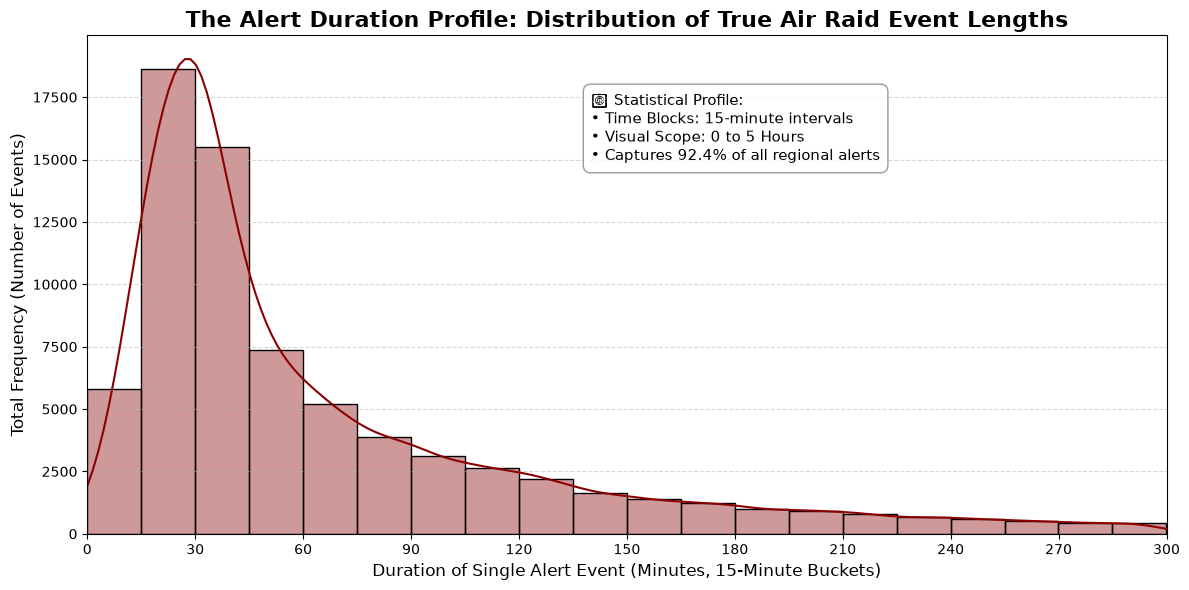

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Re-engineering duration data with hard boundaries...")

# --- DATA CLEANING & RE-FILTERING ---
# 1. Isolate standard tactical alerts under 24 hours from raw data
df_dur_clean = df_clean[df_clean['duration_minutes'] < 1440].copy()

# 2. Run Time-Union to collapse overlapping district sirens
temp_dur = df_dur_clean.sort_values(['oblast', 'started_at']).copy()
temp_dur['max_end_so_far'] = temp_dur.groupby('oblast')['finished_at'].cummax().shift()
temp_dur['max_end_so_far'] = temp_dur['max_end_so_far'].fillna(temp_dur['started_at'])
temp_dur['is_new_alert'] = temp_dur['started_at'] > temp_dur['max_end_so_far']
temp_dur['alert_id'] = temp_dur.groupby('oblast')['is_new_alert'].cumsum()

collapsed_dur = temp_dur.groupby(['oblast', 'alert_id']).agg(
    true_start=('started_at', 'min'),
    true_end=('finished_at', 'max')
).reset_index()

collapsed_dur['true_duration_minutes'] = (collapsed_dur['true_end'] - collapsed_dur['true_start']).dt.total_seconds() / 60

# 3. STRICT FILTER: Isolate standard tactical alerts (0 to 5 hours) to prevent axis blowout
df_visual = collapsed_dur[(collapsed_dur['true_duration_minutes'] > 0) & (collapsed_dur['true_duration_minutes'] <= 300)].copy()

print("Generating clean, readable duration profile...")

# --- THE VISUALIZATION ---
plt.figure(figsize=(12, 6))

# Plot with 15-minute intervals (periods longer than 10 mins)
sns.histplot(
    data=df_visual, 
    x='true_duration_minutes', 
    binwidth=15, 
    color="darkred", 
    alpha=0.4, 
    kde=True
)

# Hard boundary control to fix the squishing issue seen in image_08b7bc.png
plt.xlim(0, 300)

# Formatting and labeling
plt.title("The Alert Duration Profile: Distribution of True Air Raid Event Lengths", fontsize=16, fontweight="bold")
plt.xlabel("Duration of Single Alert Event (Minutes, 15-Minute Buckets)", fontsize=12)
plt.ylabel("Total Frequency (Number of Events)", fontsize=12)

# Set grid lines and ticks at clean 30-minute markers for easy readability
plt.xticks(range(0, 301, 30))
plt.grid(axis='y', linestyle='--', alpha=0.5)

# Clear statistical context box
total_alerts = len(collapsed_dur)
captured_alerts = len(df_visual)
pct_captured = (captured_alerts / total_alerts) * 100

plt.text(x=140, y=plt.gca().get_ylim()[1] * 0.75, 
         s=f"📊 Statistical Profile:\n"
           f"• Time Blocks: 15-minute intervals\n"
           f"• Visual Scope: 0 to 5 Hours\n"
           f"• Captures {pct_captured:.1f}% of all regional alerts", 
         fontsize=11, color="black", bbox=dict(boxstyle="round,pad=0.5", fc="white", ec="gray", alpha=0.8))

plt.tight_layout()
plt.show()